In [128]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pprint import pprint

catalogo_productos = pd.read_csv('../data/raw/catalogo_productos.csv')
especificaciones_cajas = pd.read_csv('../data/raw/especificaciones_cajas.csv')
operaciones_planta = pd.read_csv('../data/raw/operaciones_planta.csv')
procurement_cajas = pd.read_csv('../data/raw/procurement_cajas.csv')

---
embed-resources: True
format:
    html:
        page-layout: full
        fontsize: 18px

title: 'Data Cleaning'
author: 'Lorenzo Marquesini'
warning: False
toc: False
---

## Limpieza catálogo productos

**Valores nulos**

* peso_neto_paquete tiene NAN

* cantidad_paquetes tiene NAN

* Se pueden rellenar buscando coincidencias de producto, categoria, division de pesos y llenar valores faltantes

**tamaño_paquete tiene un formato raro.**

* Tal vez eliminar espacios y separar en columnas

[  '5 X 2,5 KG', '13 X 0,75 KG',   '9 X 1,5 KG',    '11 X 1 KG',
  '13 X 0,5 KG',    '13 X 1 KG',     '5x2.5 kg',   '5 X 2.5 KG',
   '5 x 2,5 kg',    '5 X2,5 KG',    '5X 2,5 KG',   '2 X 2,5 KG',
   '5 X 2,5 kg',     '5X2,5 KG',     '5 X 1 KG',  '19 X 0,5 KG',
  '2 X 4,75 KG',  '5 X 1,75 KG', '16 X 0,75 KG',  '11 X 1,5 KG',
    '5 X 2,5kg',  '11 X 0,5 KG', '11 X 0,75 KG',   '9 X 0,5 KG',
  '9 X 0,75 KG',     '5 X 2 KG',  '16 X 0,5 KG',     '2 X 3 KG']



In [129]:
catalogo_productos.head()

,codigo_producto,descripcion_producto,ingrediente_forma,tipo_proyecto,subcategoria,categoria,tamaño_corte,peso_neto_caja,tamaño_paquete,cantidad_paquetes,peso_neto_paquete,caja_tipo_id
0,BR0001,"5 bolsas de 2,5 kg | Bastones rectos de brocol...",Bastones rectos de brocoli,Estacional,Bastones clasicos - Reserva Privada,Bastones clasicos,Fino,12.50,"5 X 2,5 KG",5.0,2.50,a23eeef1c0cd8cfd40b780d65382034a
1,BR0002,Espirales de brocoli - clasico - Caja de 13 pa...,Espirales de brocoli,Forma estable,Bastones clasicos - Sigilo,Bastones clasicos,Forma,9.75,"13 X 0,75 KG",13.0,0.75,3256a5fed07b421a92abee44a3d93243
2,BR0003,Gajos de brocoli - sazonado - Caja de 13 packs...,Gajos de brocoli,Forma estable,Bastones clasicos - Sigilo,Bastones clasicos,Forma,9.75,"13 X 0,75 KG",13.0,0.75,4f08f853cf7f9be28571df66a50bc322
3,BR0004,Bastones rectos de brocoli - crocante - Caja d...,Bastones rectos de brocoli,Estacional,Bastones clasicos - Sigilo,Bastones clasicos,Grueso,11.25,"9 X 1,25 KG",9.0,1.25,c96df5913565ba35f3e02e744c9a6dde
4,BR0005,"13 bolsas de 0,75 kg | Espirales de brocoli si...",Espirales de brocoli,Forma estable,Bastones clasicos - Sigilo,Bastones clasicos,Forma,9.75,"13 X 0,75 KG",13.0,0.75,eb4895380ccaa410da0fefb6f12b197b


In [130]:
catalogo_productos.shape

(427, 12)

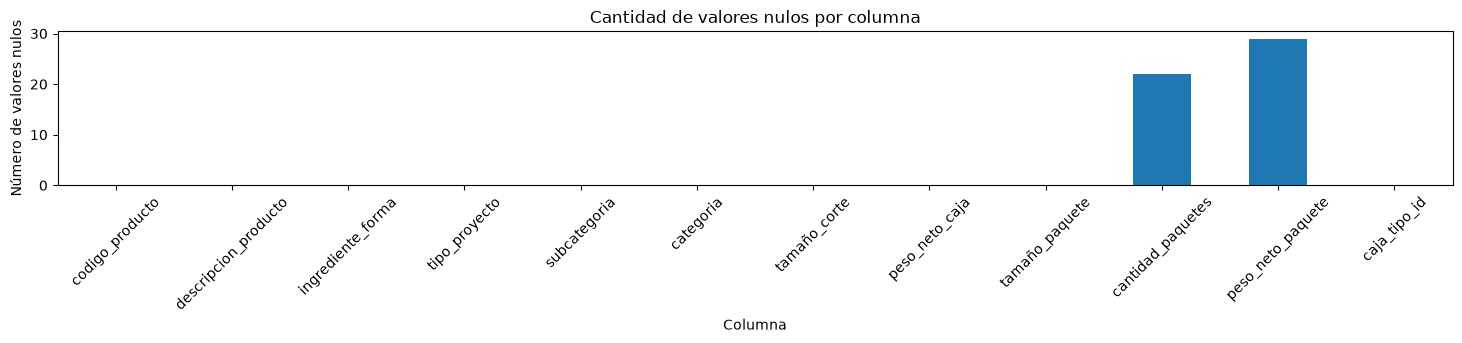

In [131]:
ax = catalogo_productos.isna().sum().plot(kind='bar', figsize=(18,2))
plt.title('Cantidad de valores nulos por columna')
plt.ylabel('Número de valores nulos')
plt.xlabel('Columna')
plt.xticks(rotation=45)
plt.show()

In [132]:
catalogo_productos.columns

Index(['codigo_producto', 'descripcion_producto', 'ingrediente_forma',
       'tipo_proyecto', 'subcategoria', 'categoria', 'tamaño_corte',
       'peso_neto_caja', 'tamaño_paquete', 'cantidad_paquetes',
       'peso_neto_paquete', 'caja_tipo_id'],
      dtype='str')

Valores unicos de incrediente forma

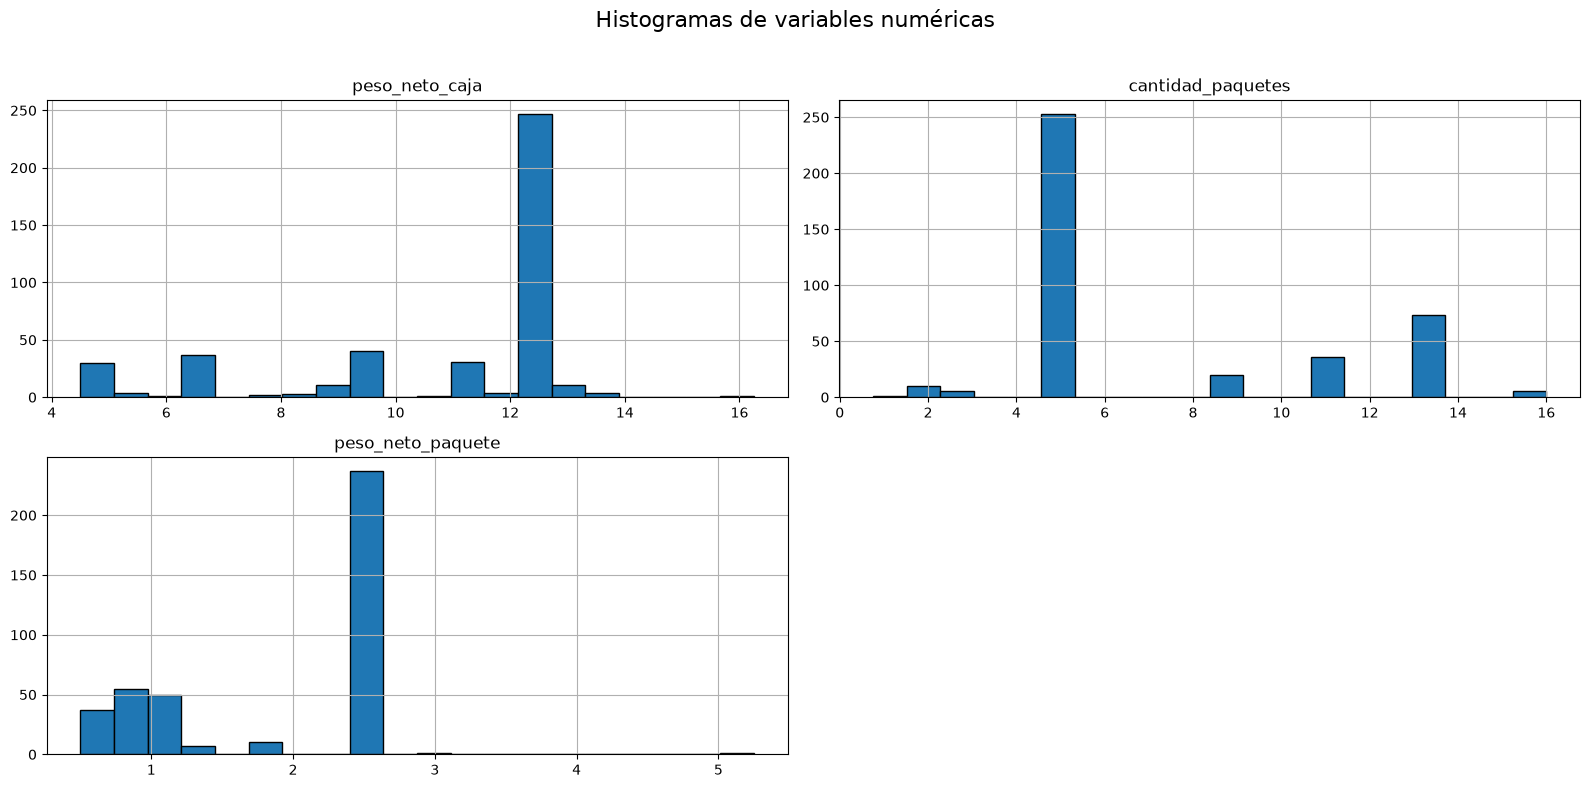

In [133]:
# Histograma de cada variable numérica
numerical_cols = catalogo_productos.select_dtypes(include=['float64', 'int64']).columns

catalogo_productos[numerical_cols].hist(bins=20, figsize=(16, 8), edgecolor='black')
plt.suptitle('Histogramas de variables numéricas', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

<hr>

### Checksums

In [134]:
catalogo_productos[['peso_neto_caja',	'tamaño_paquete',	'cantidad_paquetes',	'peso_neto_paquete']]

,peso_neto_caja,tamaño_paquete,cantidad_paquetes,peso_neto_paquete
0,12.50,"5 X 2,5 KG",5.0,2.50
1,9.75,"13 X 0,75 KG",13.0,0.75
2,9.75,"13 X 0,75 KG",13.0,0.75
3,11.25,"9 X 1,25 KG",9.0,1.25
4,9.75,"13 X 0,75 KG",13.0,0.75
...,...,...,...,...
422,8.25,"11 X 0,75 KG",11.0,0.75
423,8.25,"11X0,8 KG",NaN,NaN
424,12.50,"5 X 2,5 KG",5.0,2.50
425,12.50,"5 X 2,5 KG",5.0,2.50


In [135]:
catalogo_productos['checksums'] = catalogo_productos['cantidad_paquetes'] * catalogo_productos['peso_neto_paquete']

In [136]:
catalogo_productos[['checksums','peso_neto_caja',	'tamaño_paquete',	'cantidad_paquetes',	'peso_neto_paquete']]

,checksums,peso_neto_caja,tamaño_paquete,cantidad_paquetes,peso_neto_paquete
0,12.50,12.50,"5 X 2,5 KG",5.0,2.50
1,9.75,9.75,"13 X 0,75 KG",13.0,0.75
2,9.75,9.75,"13 X 0,75 KG",13.0,0.75
3,11.25,11.25,"9 X 1,25 KG",9.0,1.25
4,9.75,9.75,"13 X 0,75 KG",13.0,0.75
...,...,...,...,...,...
422,8.25,8.25,"11 X 0,75 KG",11.0,0.75
423,NaN,8.25,"11X0,8 KG",NaN,NaN
424,12.50,12.50,"5 X 2,5 KG",5.0,2.50
425,12.50,12.50,"5 X 2,5 KG",5.0,2.50


Valores faltantes

In [137]:
catalogo_productos[catalogo_productos['checksums'] != catalogo_productos['peso_neto_caja']].head()

,codigo_producto,descripcion_producto,ingrediente_forma,tipo_proyecto,subcategoria,categoria,tamaño_corte,peso_neto_caja,tamaño_paquete,cantidad_paquetes,peso_neto_paquete,caja_tipo_id,checksums
25,BR0026,BonsaiGreen Bastones rectos de brocoli 9x9 mm ...,Bastones rectos de brocoli,Estacional,Bastones clasicos - Mayordomo,Bastones clasicos,Medio,12.5,5 X 2.5 KG,2.5,2.5,79637c70988d89fe3abe191b59c1ed0c,6.25
27,BR0028,"5 bolsas de 2,5 kg | Bastones rectos de brocol...",Bastones rectos de brocoli,Estacional,Bastones clasicos - Mayordomo,Bastones clasicos,Medio,12.5,5 X 2.5 KG,2.5,2.5,4910b652fb2cf1c609d243a1e78d1919,6.25
31,BR0032,BonsaiGreen Bastones rectos de brocoli 13x13 m...,Bastones rectos de brocoli,Estacional,Bastones clasicos - Mayordomo,Bastones clasicos,Grueso,12.5,"5 x 2,5 kg",NaN,NaN,bfcb33e665554321d0a93ce891eadb54,NaN
32,BR0033,11 bolsas de 1 kg | Bastones rectos de brocoli...,Bastones rectos de brocoli,Estacional,Bastones clasicos - Mayordomo,Bastones clasicos,Medio,11.0,"11 X1,0 KG",11.0,NaN,a12aea41ad9864b83129274495d5d5b2,NaN
35,BR0036,BonsaiGreen Bastones rectos de brocoli 9x9 mm ...,Bastones rectos de brocoli,Estacional,Bastones clasicos - Legumes Frites,Bastones clasicos,Medio,12.5,"5X 2,5 KG",NaN,2.5,ceda63d824383fb94ca5e9bd08701d70,NaN


<hr>

In [138]:
catalogo_productos[['tamaño_paquete', 'peso_neto_caja']].drop_duplicates().sort_values('peso_neto_caja')

,tamaño_paquete,peso_neto_caja
217,"9 X 0,5 KG",4.50
75,5 X 1 KG,5.00
182,"5X 1,0 KG",5.00
42,"2 X 2,5 KG",5.00
313,"5 x 1,0 kg",5.00
306,"5 X 1,0 kg",5.00
177,"5x1,0 kg",5.00
215,"11 X 0,5 KG",5.50
305,2 X 3 KG,6.00
66,"13X0,5 KG",6.50


# Catalogo join cajas details

In [139]:
productos_joined_cajas = catalogo_productos.merge(especificaciones_cajas, on="caja_tipo_id", how="left")
productos_joined_cajas['tamaño_paquete'] = productos_joined_cajas['tamaño_paquete'].str.lower().str.replace(" ", "")

### Volumen de paquetes y peso

But you do not know the real dimensions of each package inside the box. So exact fitting is impossible unless you have package dimensions.

current_volume = caja_interior_largo * caja_interior_ancho * caja_interior_alto
volume_per_package = current_volume / cantidad_paquetes

This assumes packages scale by volume and can be rearranged freely. It is not a real geometric fit.

### Diagnóstico calidad de datos

* Valores faltantes en cantidad de paquetes y peso neto por paquete.

* Valores decimales (fracciones) en cantidad de paquetes (8 casos)

* En los valores decimales, cantidad de paquetes es lo que deberia ser el peso. Por ej, Cantidad de paquetes "2.5" cuando el tamaño_paquete es "5x2.5kg" (Estos son los casos donde no coinciden la cuenta de peso neto caja con la multiplicacion entre cantidad de productos y peso neto)


In [140]:
productos_joined_cajas[['tamaño_paquete','peso_neto_caja','peso_neto_paquete','cantidad_paquetes', 'caja_interior_largo', 'caja_interior_ancho', 'caja_interior_alto']].loc[
    lambda df: df.isna().any(axis=1)
]

,tamaño_paquete,peso_neto_caja,peso_neto_paquete,cantidad_paquetes,caja_interior_largo,caja_interior_ancho,caja_interior_alto
31,"5x2,5kg",12.50,NaN,NaN,386.0,286.0,159.0
32,"11x1,0kg",11.00,NaN,11.0,388.0,288.0,184.0
35,"5x2,5kg",12.50,2.50,NaN,384.0,286.0,163.0
36,"5x2,5kg",12.50,NaN,NaN,393.0,255.0,245.0
64,"5x2,5kg",12.50,2.50,NaN,388.0,288.0,169.0
66,"13x0,5kg",6.50,NaN,NaN,393.0,255.0,250.0
70,"11x1,0kg",11.00,NaN,11.0,393.0,255.0,219.0
80,"19x0,5kg",9.50,0.50,NaN,393.0,255.0,275.0
89,"5x2,5kg",12.50,NaN,5.0,383.0,248.0,214.0
143,"11x1,0kg",11.00,NaN,NaN,386.0,286.0,318.0


In [141]:
productos_joined_cajas.columns

Index(['codigo_producto', 'descripcion_producto', 'ingrediente_forma',
       'tipo_proyecto', 'subcategoria', 'categoria', 'tamaño_corte',
       'peso_neto_caja', 'tamaño_paquete', 'cantidad_paquetes',
       'peso_neto_paquete', 'caja_tipo_id', 'checksums', 'caja_grosor_mm',
       'caja_interior_largo', 'caja_interior_ancho', 'caja_interior_alto',
       'caja_exterior_largo', 'caja_exterior_ancho', 'caja_exterior_alto',
       'pallet_alto', 'pallet_ancho', 'pallet_largo', 'cantidad_cajas_alto',
       'cantidad_cajas_largo', 'cantidad_cajas_ancho', 'cantidad_cajas_total',
       'utilizacion'],
      dtype='str')

In [142]:
df = productos_joined_cajas.copy()

# Parse N from tamaño_paquete, e.g. "5x2,5kg" -> 5
df['cantidad_parseada_tamaño'] = (
    df['tamaño_paquete']
    .astype(str)
    .str.lower()
    .str.replace(',', '.', regex=False)
    .str.extract(r'^\s*(\d+(?:\.\d+)?)\s*x')[0]
)

df['cantidad_parseada_tamaño'] = pd.to_numeric(
    df['cantidad_parseada_tamaño'],
    errors='coerce'
)

df['cantidad_paquetes'] = pd.to_numeric(
    df['cantidad_paquetes'],
    errors='coerce'
)

# Cases where both exist but do not match
mismatch_cantidad = df[
    df['cantidad_parseada_tamaño'].notna()
    & df['cantidad_paquetes'].notna()
    & (df['cantidad_parseada_tamaño'] != df['cantidad_paquetes'])
].copy()

mismatch_cantidad[
    [
        'tamaño_paquete',
        'cantidad_parseada_tamaño',
        'cantidad_paquetes',
        'peso_neto_caja',
        'peso_neto_paquete',
        'caja_interior_largo',
        'caja_interior_ancho',
        'caja_interior_alto'
    ]
]

,tamaño_paquete,cantidad_parseada_tamaño,cantidad_paquetes,peso_neto_caja,peso_neto_paquete,caja_interior_largo,caja_interior_ancho,caja_interior_alto
25,5x2.5kg,5,2.50,12.50,2.50,388.0,288.0,219.0
27,5x2.5kg,5,2.50,12.50,2.50,386.0,286.0,217.0
156,5x2.5kg,5,2.50,12.50,2.50,386.0,286.0,204.0
175,5x1.8kg,5,1.75,8.75,1.75,386.0,286.0,164.0
249,5x2.5kg,5,2.50,12.50,2.50,385.0,255.0,318.0
275,5x2.5kg,5,2.50,12.50,2.50,386.0,286.0,214.0
281,13x0.8kg,13,0.75,9.75,0.75,386.0,286.0,263.0
366,5x2.5kg,5,2.50,12.50,2.50,386.0,286.0,164.0


In [143]:
df = productos_joined_cajas.copy()

df['peso_calculado_caja'] = df['cantidad_paquetes'] * df['peso_neto_paquete']

mismatch_peso = df[
    df['peso_neto_caja'].notna()
    & df['cantidad_paquetes'].notna()
    & df['peso_neto_paquete'].notna()
    & ~np.isclose(df['peso_neto_caja'], df['peso_calculado_caja'])
]

mismatch_peso[
    [
        'tamaño_paquete',
        'peso_neto_caja',
        'cantidad_paquetes',
        'peso_neto_paquete',
        'peso_calculado_caja'
    ]
]

,tamaño_paquete,peso_neto_caja,cantidad_paquetes,peso_neto_paquete,peso_calculado_caja
25,5x2.5kg,12.50,2.50,2.50,6.2500
27,5x2.5kg,12.50,2.50,2.50,6.2500
156,5x2.5kg,12.50,2.50,2.50,6.2500
175,5x1.8kg,8.75,1.75,1.75,3.0625
249,5x2.5kg,12.50,2.50,2.50,6.2500
275,5x2.5kg,12.50,2.50,2.50,6.2500
281,13x0.8kg,9.75,0.75,0.75,0.5625
366,5x2.5kg,12.50,2.50,2.50,6.2500


## 1. Consistencia de cantidad de paquetes

* No puede ser decimal

In [144]:
producto_joined_cajas_clean = productos_joined_cajas.copy()

In [145]:
df = producto_joined_cajas_clean.copy()

# Parse N from tamaño_paquete: "5x2.5kg" -> 5
df['cantidad_parseada'] = (
    df['tamaño_paquete']
    .astype(str)
    .str.lower()
    .str.replace(',', '.', regex=False)
    .str.extract(r'^\s*(\d+(?:\.\d+)?)\s*x')[0]
)

df['cantidad_parseada'] = pd.to_numeric(df['cantidad_parseada'], errors='coerce')
df['cantidad_paquetes'] = pd.to_numeric(df['cantidad_paquetes'], errors='coerce')

# Detect decimal quantities
mask_decimal = (
    df['cantidad_paquetes'].notna()
    & ~np.isclose(df['cantidad_paquetes'] % 1, 0)
    & df['cantidad_parseada'].notna()
)

# Optional: inspect before changing
df.loc[
    mask_decimal,
    ['tamaño_paquete', 'cantidad_paquetes', 'cantidad_parseada', 'peso_neto_caja', 'peso_neto_paquete']
]

,tamaño_paquete,cantidad_paquetes,cantidad_parseada,peso_neto_caja,peso_neto_paquete
25,5x2.5kg,2.50,5,12.50,2.50
27,5x2.5kg,2.50,5,12.50,2.50
156,5x2.5kg,2.50,5,12.50,2.50
175,5x1.8kg,1.75,5,8.75,1.75
249,5x2.5kg,2.50,5,12.50,2.50
275,5x2.5kg,2.50,5,12.50,2.50
281,13x0.8kg,0.75,13,9.75,0.75
366,5x2.5kg,2.50,5,12.50,2.50


In [146]:
df.loc[mask_decimal, 'cantidad_paquetes'] = df.loc[mask_decimal, 'cantidad_parseada']

# Optional: force integer
df.loc[df['cantidad_paquetes'].notna(), 'cantidad_paquetes'] = df.loc[df['cantidad_paquetes'].notna(), 'cantidad_paquetes'].astype(int)

producto_joined_cajas_clean = df.drop(columns=['cantidad_parseada'])

In [147]:
producto_joined_cajas_clean[
    producto_joined_cajas_clean['cantidad_paquetes'] % 1 != 0
]

,codigo_producto,descripcion_producto,ingrediente_forma,tipo_proyecto,subcategoria,categoria,tamaño_corte,peso_neto_caja,tamaño_paquete,cantidad_paquetes,...,caja_exterior_ancho,caja_exterior_alto,pallet_alto,pallet_ancho,pallet_largo,cantidad_cajas_alto,cantidad_cajas_largo,cantidad_cajas_ancho,cantidad_cajas_total,utilizacion
31,BR0032,BonsaiGreen Bastones rectos de brocoli 13x13 m...,Bastones rectos de brocoli,Estacional,Bastones clasicos - Mayordomo,Bastones clasicos,Grueso,12.50,"5x2,5kg",NaN,...,294.2,167.2,1800,800,1200,10.0,2.0,4.0,80.0,0.897722
35,BR0036,BonsaiGreen Bastones rectos de brocoli 9x9 mm ...,Bastones rectos de brocoli,Estacional,Bastones clasicos - Legumes Frites,Bastones clasicos,Medio,12.50,"5x2,5kg",NaN,...,295.6,172.6,1800,800,1200,10.0,2.0,4.0,80.0,0.929708
36,BR0037,Bastones rectos de brocoli 9x9 mm - sazonado -...,Bastones rectos de brocoli,Estacional,Bastones clasicos - Sigilo,Bastones clasicos,Medio,12.50,"5x2,5kg",NaN,...,260.4,250.4,1800,800,1200,7.0,2.0,4.0,56.0,0.841858
64,BR0065,Bastones rectos de brocoli - clasico - Caja de...,Bastones rectos de brocoli,Estacional,Bastones clasicos - Sigilo,Bastones clasicos,Grueso,12.50,"5x2,5kg",NaN,...,296.2,177.2,1800,800,1200,10.0,2.0,4.0,80.0,0.962741
66,BR0067,"13 bolsas de 0,5 kg | Tiras para dip de brocol...",Tiras para dip de brocoli,Forma estable,Bastones clasicos - Sigilo,Bastones clasicos,Forma,6.50,"13x0,5kg",NaN,...,260.4,255.4,1800,800,1200,7.0,2.0,4.0,56.0,0.858668
80,BR0081,"19 bolsas de 0,5 kg | Tiras para dip de brocol...",Tiras para dip de brocoli,Forma estable,Bastones clasicos - Sigilo,Bastones clasicos,Forma,9.50,"19x0,5kg",NaN,...,260.4,280.4,1800,800,1200,6.0,2.0,4.0,NaN,0.808046
143,BR0142,Brocoli en rejilla - clasico - Caja de 11 pack...,Brocoli en rejilla,Forma estable,Bastones clasicos - Sigilo,Bastones clasicos,Forma,11.00,"11x1,0kg",NaN,...,294.2,326.2,1800,800,1200,5.0,2.0,4.0,40.0,0.875708
182,BR0181,Bocados de brocoli con queso cheddar - picante...,Bocados de brocoli con queso cheddar,Co-produccion,Snacks y aperitivos - Queso,Snacks y aperitivos,Forma,5.00,"5x1,0kg",NaN,...,260.4,173.4,1800,800,1200,10.0,2.0,4.0,NaN,0.832829
194,BR0193,Brocoli zigzag 9x9 mm - clasico - Caja de 5 pa...,Brocoli zigzag,Forma estable,Bastones clasicos - Sigilo,Bastones clasicos,Forma,12.50,"5x2,5kg",NaN,...,260.4,291.4,1800,800,1200,6.0,2.0,4.0,48.0,0.839745
270,BR0268,BonsaiGreen Bastones rectos de brocoli 9x9 mm ...,Bastones rectos de brocoli,Estacional,Bastones clasicos - Legumes Frites,Bastones clasicos,Medio,12.50,"5x2,5kg",NaN,...,294.2,187.2,1800,800,1200,9.0,2.0,4.0,NaN,0.904594


## 2. Tratamiento de NAs

* Faltantes en cantidad de cajas

* Cantidad de paquetes

* Peso neto por paquete

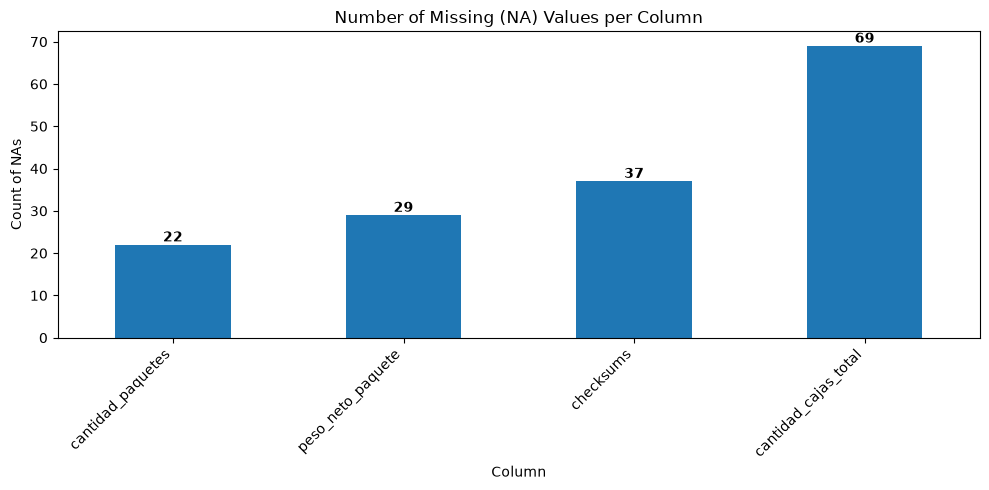

In [148]:
def plot_na(df):
    """
    Plots the number of missing (NA) values per column for a given DataFrame.
    Only columns with at least one missing value will be shown.
    """
    na_counts = df.isna().sum()
    na_counts = na_counts[na_counts > 0]  # Only show columns with at least 1 NA

    plt.figure(figsize=(10, 5))
    ax = na_counts.plot(kind='bar')
    plt.title('Number of Missing (NA) Values per Column')
    plt.ylabel('Count of NAs')
    plt.xlabel('Column')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()

    # Add annotations (n) on top of each bar
    for p in ax.patches:
        height = p.get_height()
        ax.annotate(
            f'{int(height)}',
            (p.get_x() + p.get_width() / 2, height),
            ha='center', va='bottom', fontsize=10, fontweight='bold'
        )

    plt.show()

plot_na(producto_joined_cajas_clean)

### Cantidad_paquetes & Peso_neto_paquete NA treatment

In [149]:
producto_joined_cajas_clean[['tamaño_paquete', 'cantidad_paquetes', 'peso_neto_paquete', 'peso_neto_caja']].loc[
    lambda df: df.isna().any(axis=1)
]

,tamaño_paquete,cantidad_paquetes,peso_neto_paquete,peso_neto_caja
31,"5x2,5kg",NaN,NaN,12.50
32,"11x1,0kg",11.0,NaN,11.00
35,"5x2,5kg",NaN,2.50,12.50
36,"5x2,5kg",NaN,NaN,12.50
64,"5x2,5kg",NaN,2.50,12.50
66,"13x0,5kg",NaN,NaN,6.50
70,"11x1,0kg",11.0,NaN,11.00
80,"19x0,5kg",NaN,0.50,9.50
89,"5x2,5kg",5.0,NaN,12.50
143,"11x1,0kg",NaN,NaN,11.00


In [150]:
def fill_na_cantidad_paquetes_peso_neto_paquete(df):
    df = df.copy()

    # -----------------------------
    # Auxiliares desde tamaño_paquete
    # Ej: "5x2,5kg" -> cantidad=5, peso_formato=2.5
    # -----------------------------
    s = (
        df['tamaño_paquete']
        .astype(str)
        .str.lower()
        .str.strip()
        .str.replace(',', '.', regex=False)
    )

    df['tamaño_paquete_cantidad'] = pd.to_numeric(
        s.str.extract(r'^\s*(\d+(?:\.\d+)?)\s*x')[0],
        errors='coerce'
    )

    df['tamaño_paquete_peso'] = pd.to_numeric(
        s.str.extract(r'x\s*(\d+(?:\.\d+)?)\s*kg?')[0],
        errors='coerce'
    )

    # -----------------------------
    # Asegurar numéricos
    # -----------------------------
    num_cols = [
        'peso_neto_caja',
        'peso_neto_paquete',
        'cantidad_paquetes',
        'tamaño_paquete_cantidad',
        'tamaño_paquete_peso'
    ]

    for col in num_cols:
        df[col] = pd.to_numeric(df[col], errors='coerce')

    # -----------------------------
    # Caso 0:
    # Si cantidad_paquetes es decimal, probablemente está mal cargada.
    # La reemplazamos por el N parseado del tamaño_paquete.
    # -----------------------------
    mask_decimal_qty = (
        df['cantidad_paquetes'].notna()
        & ~np.isclose(df['cantidad_paquetes'] % 1, 0)
        & df['tamaño_paquete_cantidad'].notna()
    )

    df.loc[mask_decimal_qty, 'cantidad_paquetes'] = (
        df.loc[mask_decimal_qty, 'tamaño_paquete_cantidad']
    )

    # -----------------------------
    # Caso 1:
    # Falta cantidad_paquetes
    # Tenemos peso_neto_paquete y peso_neto_caja
    # -----------------------------
    qty_calc = df['peso_neto_caja'] / df['peso_neto_paquete']

    mask_fill_qty_from_weight = (
        df['cantidad_paquetes'].isna()
        & df['peso_neto_caja'].notna()
        & df['peso_neto_paquete'].notna()
        & (df['peso_neto_paquete'] > 0)
        & np.isclose(qty_calc % 1, 0, atol=1e-6)
    )

    df.loc[mask_fill_qty_from_weight, 'cantidad_paquetes'] = (
        qty_calc[mask_fill_qty_from_weight].round()
    )

    # -----------------------------
    # Caso 2:
    # Falta cantidad_paquetes
    # Usamos el N del tamaño_paquete
    # -----------------------------
    mask_fill_qty_from_tamano = (
        df['cantidad_paquetes'].isna()
        & df['tamaño_paquete_cantidad'].notna()
    )

    df.loc[mask_fill_qty_from_tamano, 'cantidad_paquetes'] = (
        df.loc[mask_fill_qty_from_tamano, 'tamaño_paquete_cantidad']
    )

    # -----------------------------
    # Caso 3:
    # Falta peso_neto_paquete
    # Tenemos peso_neto_caja y cantidad_paquetes
    # -----------------------------
    mask_fill_unit_weight = (
        df['peso_neto_paquete'].isna()
        & df['peso_neto_caja'].notna()
        & df['cantidad_paquetes'].notna()
        & (df['cantidad_paquetes'] > 0)
    )

    df.loc[mask_fill_unit_weight, 'peso_neto_paquete'] = (
        df.loc[mask_fill_unit_weight, 'peso_neto_caja']
        / df.loc[mask_fill_unit_weight, 'cantidad_paquetes']
    )

    # -----------------------------
    # Revisión de consistencia
    # -----------------------------
    df['peso_calculado_caja'] = (
        df['cantidad_paquetes'] * df['peso_neto_paquete']
    )

    df['peso_caja_ok'] = np.isclose(
        df['peso_neto_caja'],
        df['peso_calculado_caja'],
        atol=0.01,
        equal_nan=False
    )

    df['cantidad_ok_tamano'] = np.isclose(
        df['cantidad_paquetes'],
        df['tamaño_paquete_cantidad'],
        atol=0.01,
        equal_nan=False
    )

    # Cantidad debería ser entera
    df['cantidad_paquetes'] = df['cantidad_paquetes'].round().astype('Int64')

    return df

In [151]:
producto_joined_cajas_clean = fill_na_cantidad_paquetes_peso_neto_paquete(
    producto_joined_cajas_clean
)

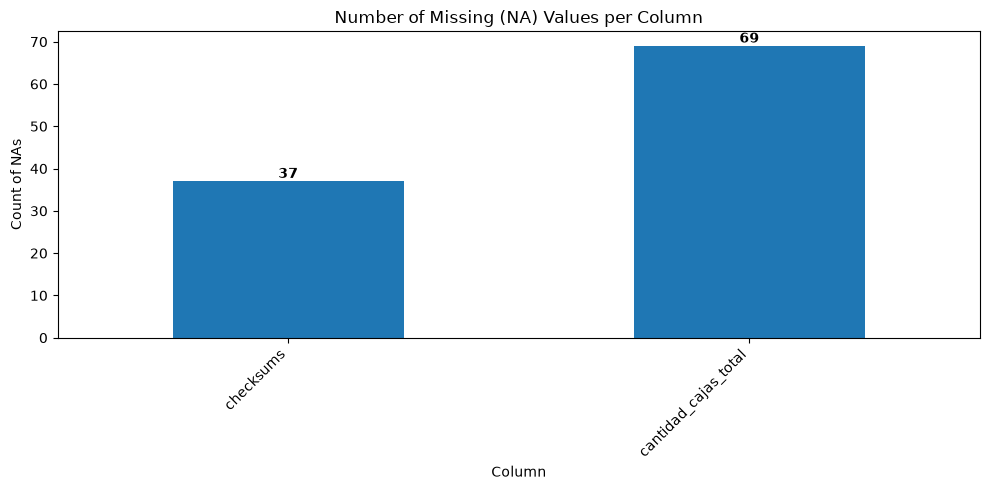

In [152]:
plot_na(producto_joined_cajas_clean)

### Cantidad de cajas total

In [153]:
producto_joined_cajas_clean.columns

Index(['codigo_producto', 'descripcion_producto', 'ingrediente_forma',
       'tipo_proyecto', 'subcategoria', 'categoria', 'tamaño_corte',
       'peso_neto_caja', 'tamaño_paquete', 'cantidad_paquetes',
       'peso_neto_paquete', 'caja_tipo_id', 'checksums', 'caja_grosor_mm',
       'caja_interior_largo', 'caja_interior_ancho', 'caja_interior_alto',
       'caja_exterior_largo', 'caja_exterior_ancho', 'caja_exterior_alto',
       'pallet_alto', 'pallet_ancho', 'pallet_largo', 'cantidad_cajas_alto',
       'cantidad_cajas_largo', 'cantidad_cajas_ancho', 'cantidad_cajas_total',
       'utilizacion', 'tamaño_paquete_cantidad', 'tamaño_paquete_peso',
       'peso_calculado_caja', 'peso_caja_ok', 'cantidad_ok_tamano'],
      dtype='str')

In [154]:
def validate_cantidad_cajas_total(df, pallet_largo=1200, pallet_ancho=800, pallet_alto=1800):
    """
    Valida que la cantidad total de cajas que se declaran caben físicamente
    en un pallet dado el tamaño exterior de la caja y el tamaño del pallet.

    Supuestos:
    - El largo exterior de la caja se alinea con el ancho del pallet (800mm).
    - El ancho exterior de la caja se alinea con el largo del pallet (1200mm).
    - El alto exterior de la caja se apila usando pallet_alto (1800mm por defecto).

    Calcula la cantidad máxima posible que cabe en cada dirección, 
    valida si la cantidad declarada cabe, y calcula el exceso si corresponde.
    """
    df = df.copy()

    # Ensure columns are numeric for calculation stability
    cols = [
        'caja_exterior_largo',
        'caja_exterior_ancho',
        'caja_exterior_alto',
        'cantidad_cajas_total'
    ]

    for col in cols:
        df[col] = pd.to_numeric(df[col], errors='coerce')  # posibles nulos etc

    # Calcula cuántas cajas caben en el ancho del pallet
    # (lado largo de la caja en lado corto del pallet)
    df['max_cajas_en_ancho_pallet'] = np.floor(
        pallet_ancho / df['caja_exterior_largo']
    )

    # Calcula cuántas cajas caben en el largo del pallet
    # (lado corto de la caja en lado largo del pallet)
    df['max_cajas_en_largo_pallet'] = np.floor(
        pallet_largo / df['caja_exterior_ancho']
    )

    # Calcula cuántas cajas caben en el alto del pallet
    df['max_cajas_en_alto_pallet'] = np.floor(
        pallet_alto / df['caja_exterior_alto']
    )

    # Multiplica para obtener el número máximo de cajas en el pallet
    df['max_cajas_total_pallet'] = (
        df['max_cajas_en_ancho_pallet']
        * df['max_cajas_en_largo_pallet']
        * df['max_cajas_en_alto_pallet']
    )

    # La validación principal: ¿la cantidad declarada no excede el máximo posible?
    df['cantidad_cajas_total_ok'] = (
        df['cantidad_cajas_total'] <= df['max_cajas_total_pallet']
    )

    # Diagnóstico adicional: diferencia de exceso si la hay (puede ser negativo)
    df['exceso_cajas'] = (
        df['cantidad_cajas_total'] - df['max_cajas_total_pallet']
    )

    return df

In [155]:
producto_joined_cajas_clean = validate_cantidad_cajas_total(
    producto_joined_cajas_clean
)

In [156]:
producto_joined_cajas_clean.loc[
    ~producto_joined_cajas_clean['cantidad_cajas_total_ok'],
    [
        'codigo_producto',
        'caja_exterior_largo',
        'caja_exterior_ancho',
        'caja_exterior_alto',
        'cantidad_cajas_total',
        'max_cajas_en_ancho_pallet',
        'max_cajas_en_largo_pallet',
        'max_cajas_en_alto_pallet',
        'max_cajas_total_pallet',
        'exceso_cajas'
    ]
]

,codigo_producto,caja_exterior_largo,caja_exterior_ancho,caja_exterior_alto,cantidad_cajas_total,max_cajas_en_ancho_pallet,max_cajas_en_largo_pallet,max_cajas_en_alto_pallet,max_cajas_total_pallet,exceso_cajas
4,BR0005,394.2,294.2,261.2,NaN,2.0,4.0,6.0,48.0,NaN
8,BR0009,394.2,294.2,187.2,NaN,2.0,4.0,9.0,72.0,NaN
13,BR0014,394.2,294.2,252.2,NaN,2.0,4.0,7.0,56.0,NaN
14,BR0015,394.2,294.2,252.2,NaN,2.0,4.0,7.0,56.0,NaN
15,BR0016,394.2,294.2,252.2,NaN,2.0,4.0,7.0,56.0,NaN
...,...,...,...,...,...,...,...,...,...,...
408,BR0403,391.2,256.2,326.2,NaN,2.0,4.0,5.0,40.0,NaN
410,BR0405,394.2,294.2,187.2,NaN,2.0,4.0,9.0,72.0,NaN
419,BR0414,394.2,294.2,187.2,NaN,2.0,4.0,9.0,72.0,NaN
421,BR0416,394.2,294.2,187.2,NaN,2.0,4.0,9.0,72.0,NaN


#### Fix NA en cantidad total de cajas

In [157]:
producto_joined_cajas_clean[['pallet_largo', 'pallet_ancho', 'pallet_alto']].drop_duplicates()

,pallet_largo,pallet_ancho,pallet_alto
0,1200,800,1800


Relleno NA

In [158]:
# Rellenar NA en 'cantidad_cajas_total' con la multiplicación de alto, ancho y largo
mask = (
    producto_joined_cajas_clean['cantidad_cajas_total'].isna()
    & producto_joined_cajas_clean['cantidad_cajas_alto'].notna()
    & producto_joined_cajas_clean['cantidad_cajas_ancho'].notna()
    & producto_joined_cajas_clean['cantidad_cajas_largo'].notna()
)

producto_joined_cajas_clean.loc[mask, 'cantidad_cajas_total'] = (
    producto_joined_cajas_clean.loc[mask, 'cantidad_cajas_alto'] *
    producto_joined_cajas_clean.loc[mask, 'cantidad_cajas_ancho'] *
    producto_joined_cajas_clean.loc[mask, 'cantidad_cajas_largo']
)

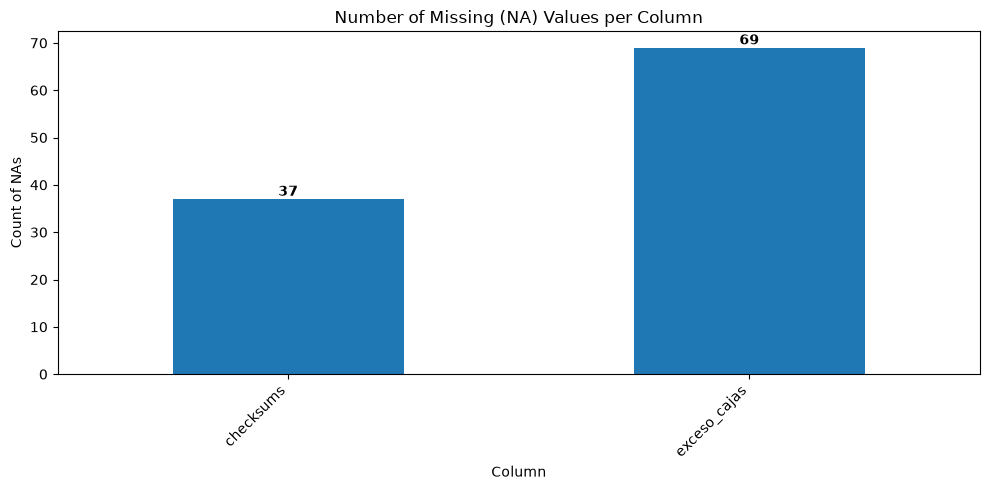

In [159]:
plot_na(producto_joined_cajas_clean)

## 3. Remove unusued columns

* Remove checksums

* Remove exceso_cajas

In [160]:
producto_joined_cajas_clean.drop(columns=['exceso_cajas','checksums'])

,codigo_producto,descripcion_producto,ingrediente_forma,tipo_proyecto,subcategoria,categoria,tamaño_corte,peso_neto_caja,tamaño_paquete,cantidad_paquetes,...,tamaño_paquete_cantidad,tamaño_paquete_peso,peso_calculado_caja,peso_caja_ok,cantidad_ok_tamano,max_cajas_en_ancho_pallet,max_cajas_en_largo_pallet,max_cajas_en_alto_pallet,max_cajas_total_pallet,cantidad_cajas_total_ok
0,BR0001,"5 bolsas de 2,5 kg | Bastones rectos de brocol...",Bastones rectos de brocoli,Estacional,Bastones clasicos - Reserva Privada,Bastones clasicos,Fino,12.50,"5x2,5kg",5,...,5,2.50,12.50,True,True,2.0,4.0,5.0,40.0,True
1,BR0002,Espirales de brocoli - clasico - Caja de 13 pa...,Espirales de brocoli,Forma estable,Bastones clasicos - Sigilo,Bastones clasicos,Forma,9.75,"13x0,75kg",13,...,13,0.75,9.75,True,True,2.0,3.0,6.0,36.0,True
2,BR0003,Gajos de brocoli - sazonado - Caja de 13 packs...,Gajos de brocoli,Forma estable,Bastones clasicos - Sigilo,Bastones clasicos,Forma,9.75,"13x0,75kg",13,...,13,0.75,9.75,True,True,2.0,4.0,10.0,80.0,True
3,BR0004,Bastones rectos de brocoli - crocante - Caja d...,Bastones rectos de brocoli,Estacional,Bastones clasicos - Sigilo,Bastones clasicos,Grueso,11.25,"9x1,25kg",9,...,9,1.25,11.25,True,True,2.0,3.0,7.0,42.0,True
4,BR0005,"13 bolsas de 0,75 kg | Espirales de brocoli si...",Espirales de brocoli,Forma estable,Bastones clasicos - Sigilo,Bastones clasicos,Forma,9.75,"13x0,75kg",13,...,13,0.75,9.75,True,True,2.0,4.0,6.0,48.0,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
422,BR0417,Mix crujiente de brocoli - clasico - Caja de 1...,Mix crujiente de brocoli,Forma estable,Bastones clasicos - Sigilo,Bastones clasicos,Forma,8.25,"11x0,75kg",11,...,11,0.75,8.25,True,True,2.0,4.0,7.0,56.0,True
423,BR0418,"BonsaiGreen Mix crujiente de brocoli 11 x 0,75 kg",Mix crujiente de brocoli,Forma estable,Bastones clasicos - Sigilo,Bastones clasicos,Forma,8.25,"11x0,8kg",11,...,11,0.80,8.25,True,True,2.0,4.0,7.0,56.0,True
424,BR0419,"5 bolsas de 2,5 kg | Bastones rectos de brocol...",Bastones rectos de brocoli,Estacional,Bastones clasicos - Reserva Privada,Bastones clasicos,Corte steak,12.50,"5x2,5kg",5,...,5,2.50,12.50,True,True,2.0,3.0,10.0,60.0,True
425,BR0420,"5 bolsas de 2,5 kg | Bastones rectos de brocol...",Bastones rectos de brocoli,Estacional,Bastones clasicos - Reserva Privada,Bastones clasicos,Medio,12.50,"5x2,5kg",5,...,5,2.50,12.50,True,True,2.0,4.0,8.0,64.0,True


## 4. Correct grosor format

In [161]:
producto_joined_cajas_clean['caja_grosor_mm'].value_counts()

caja_grosor_mm
4.1       162
2.7       142
4.8        28
4.6        25
4.1mm      13
2.70       10
4,6         8
4.6 mm      5
4.5         5
2.7 mm      4
2.5 mm      4
4.10        3
4.1 mm      3
4,1         3
4.8mm       2
4.80        2
2,7         2
4.7         2
4,8         1
2,5         1
2.50        1
2.5         1
Name: count, dtype: int64

In [162]:
def clean_grosor_mm(s):
    return (
        s.astype(str)
         .str.lower()
         .str.replace("mm", "", regex=False)
         .str.replace(",", ".", regex=False)
         .str.strip()
         .str.extract(r"(\d+(?:\.\d+)?)")[0]
         .pipe(pd.to_numeric, errors="coerce")
         .round(2)
    )

producto_joined_cajas_clean["caja_grosor_mm"] = clean_grosor_mm(
    producto_joined_cajas_clean["caja_grosor_mm"]
)

producto_joined_cajas_clean["caja_grosor_mm"].value_counts(dropna=False)

caja_grosor_mm
4.1    184
2.7    158
4.6     38
4.8     33
2.5      7
4.5      5
4.7      2
Name: count, dtype: int64

## 5. Consistency Testing

### Pesos de caja y paquetes

In [163]:
producto_joined_cajas_clean[
    producto_joined_cajas_clean['peso_neto_paquete'] * producto_joined_cajas_clean['cantidad_paquetes'] != producto_joined_cajas_clean['peso_neto_caja']
][['cantidad_paquetes', 'peso_neto_paquete', 'peso_neto_caja']]

,cantidad_paquetes,peso_neto_paquete,peso_neto_caja


<hr>

Save

In [164]:
producto_joined_cajas_clean.to_csv('../data/processed/producto_joined_cajas_clean.csv', index=False)